In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv(r"C:\Users\ivana\OneDrive\Desktop\Machine learning\winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Text(0.5, 1.0, 'Wine Quality Distribution')

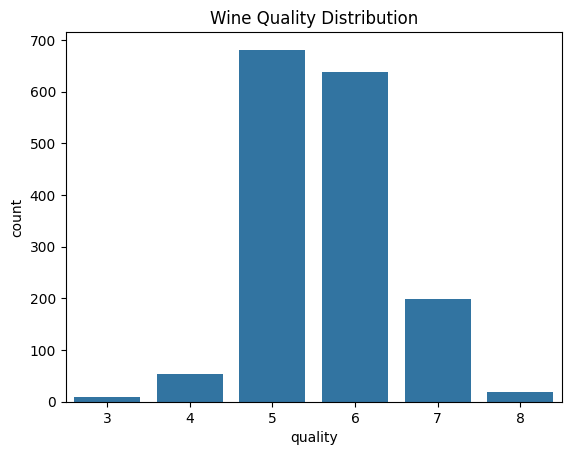

In [3]:
df.info()
df.describe()
df['quality'].value_counts()
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")

Text(0.5, 1.0, 'Class Distribution')

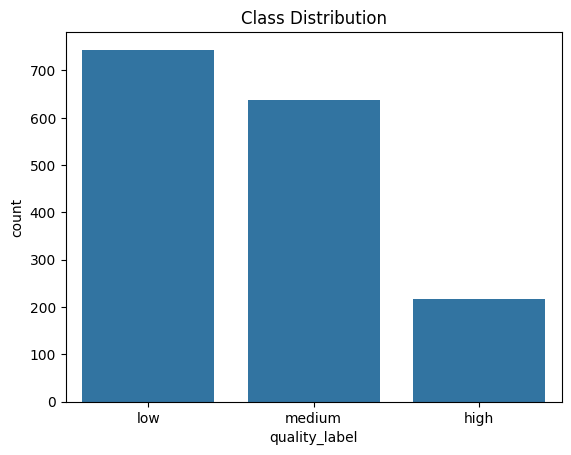

In [4]:
def quality_label(q):
    if q <= 5:
        return 'low'
    elif q == 6:
        return 'medium'
    else:
        return 'high'

df['quality_label'] = df['quality'].apply(quality_label)
df['quality_label'] = pd.Categorical(df['quality_label'], categories=['low', 'medium', 'high'])

sns.countplot(x='quality_label', data=df)
plt.title("Class Distribution")


In [5]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
knn = KNeighborsClassifier(n_neighbors=5)  # You can try k=3, 7, etc.
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [9]:
y_pred = knn.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[ 23   5  15]
 [  7 105  37]
 [ 19  43  66]]

Classification Report:
               precision    recall  f1-score   support

        high       0.47      0.53      0.50        43
         low       0.69      0.70      0.70       149
      medium       0.56      0.52      0.54       128

    accuracy                           0.61       320
   macro avg       0.57      0.59      0.58       320
weighted avg       0.61      0.61      0.61       320

Accuracy: 0.60625


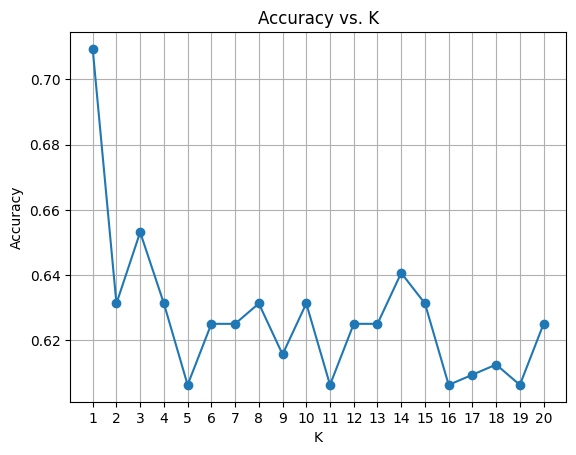

In [10]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

plt.plot(k_range, accuracies, marker='o')
plt.title("Accuracy vs. K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Predict
y_pred_dt = dtree.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.684375
              precision    recall  f1-score   support

        high       0.56      0.58      0.57        43
         low       0.76      0.76      0.76       149
      medium       0.64      0.63      0.64       128

    accuracy                           0.68       320
   macro avg       0.65      0.66      0.65       320
weighted avg       0.68      0.68      0.68       320



In [13]:
from sklearn.neural_network import MLPClassifier

# Train ANN
ann = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
ann.fit(X_train_scaled, y_train)

# Predict
y_pred_ann = ann.predict(X_test_scaled)

# Evaluate
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))


ANN Accuracy: 0.71875
              precision    recall  f1-score   support

        high       0.65      0.56      0.60        43
         low       0.80      0.77      0.78       149
      medium       0.66      0.72      0.69       128

    accuracy                           0.72       320
   macro avg       0.70      0.68      0.69       320
weighted avg       0.72      0.72      0.72       320



In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.60625


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
scores_dt = cross_val_score(dtree, X, y, cv=5)

print("Decision Tree CV Accuracy Scores:", scores_dt)
print("Average CV Accuracy:", scores_dt.mean())


Decision Tree CV Accuracy Scores: [0.590625   0.528125   0.51875    0.478125   0.51724138]
Average CV Accuracy: 0.5265732758620689


In [16]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
scores_ann = cross_val_score(ann, X_train_scaled, y_train, cv=5)

print("ANN CV Accuracy Scores:", scores_ann)
print("Average CV Accuracy:", scores_ann.mean())


C:\Users\ivana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN CV Accuracy Scores: [0.62890625 0.6875     0.65234375 0.62890625 0.67843137]
Average CV Accuracy: 0.655217524509804


C:\Users\ivana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
